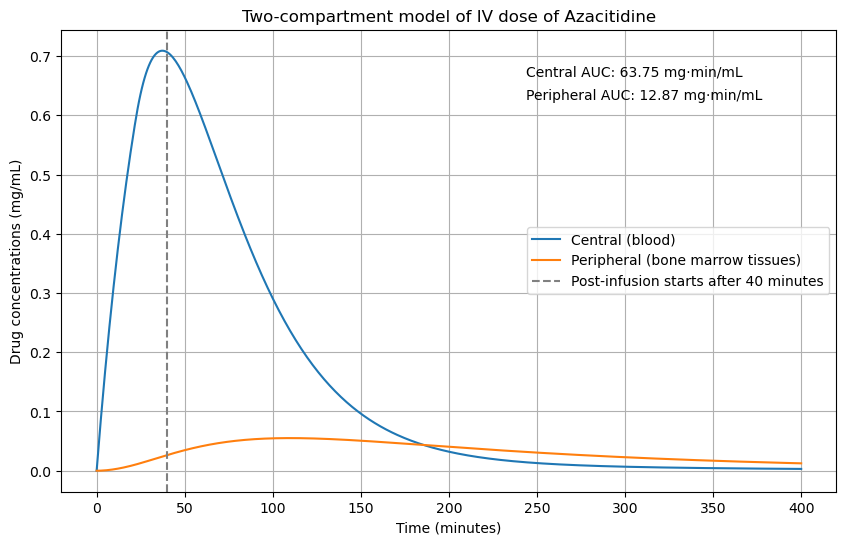

In [3]:
'''
Compartment model for intravenous dose of azacitidine
'''
from scipy.integrate import trapezoid 
import numpy as np 
from scipy.integrate import odeint
import matplotlib.pyplot as plt 

#initialize the parameters 
R0 = 2.863  #171.35 mL/hr  (rate of infusion)
V1 = 76      #L (total volume of distribution of both compartments, so like blood + tissues) 

k10 = 0.03151 #1.8902 #hr  #0.03151 in minutes   #1/hr (elimination rate)
k12 = 0.00149  #0.0892  #assumption that the k12 is leaving so clearance into the peripheral to get the numbers - 
k21 = 0.00641   #0.3847 (Q/volume of the intercompartment model)

decay_rate = 0.03151 #also known as the elimination constant
decay_start = 22 #time when decay begins 

infusion_rates = [] 

#define the function
def two_compart(y, t):
    C1, C2 = y 

    if t<= decay_start: 
        infusion = R0/V1 
    else: 
        time_since_decay = t - decay_start
        infusion = (R0/V1) * np.exp(-decay_rate * time_since_decay)

        infusion_rates.append(infusion)
        
    dC1dt = infusion - (k10 + k12)*C1 + k21*C2 
    dC2dt = k12*C1 - k21*C2 

    return [dC1dt, dC2dt] 

#initial concentrations 
y0 = [0, 0] 


t = np.linspace(0, 400, 500) 

#Solve ODE
solution = odeint(two_compart, y0, t) 

C1 = solution[:, 0] 
C2 = solution[:, 1] 

#Trapezoidal rule to find the area under the curve (numerical integration) 
auc_central = trapezoid(C1, t)     #np.trapezoid(C1, t) 
auc_peripheral = trapezoid(C2, t)         #np.trapezoid(C2, t) 

#Plot 
plt.figure(figsize=(10, 6))
plt.plot(t, C1, label = "Central (blood)") 
plt.plot(t, C2, label = "Peripheral (bone marrow tissues)") 

plt.axvline(x=40, color='0.5', linestyle='--', label='Post-infusion starts after 40 minutes')
plt.xlabel("Time (minutes)") 
plt.ylabel("Drug concentrations (mg/mL)") 
plt.grid(True) 
plt.title("Two-compartment model of IV dose of Azacitidine") 
plt.annotate(f"Central AUC: {auc_central:.2f} mg·min/mL", xy=(0.6, 0.9), xycoords='axes fraction')
plt.annotate(f"Peripheral AUC: {auc_peripheral:.2f} mg·min/mL", xy=(0.6, 0.85), xycoords='axes fraction')
             
plt.legend()
plt.show() 

#AUC units: mg * min/mL 

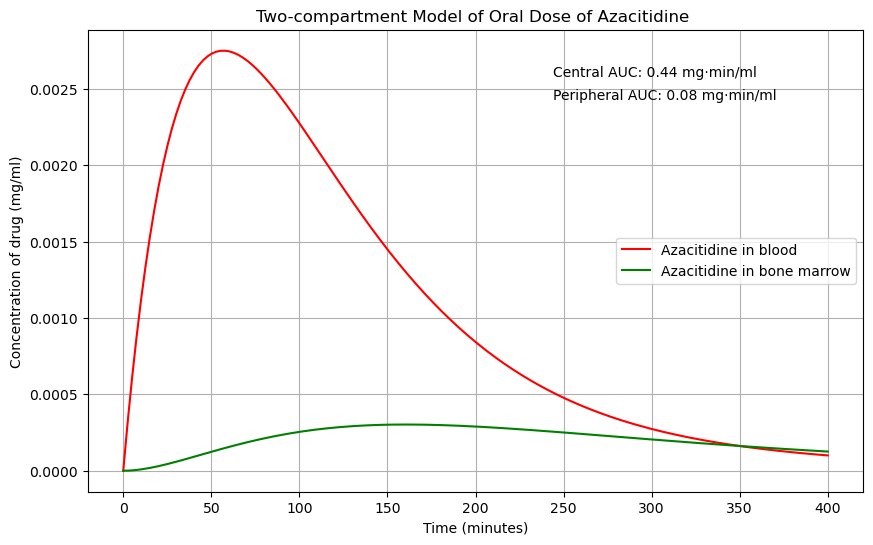

In [4]:
'''
Compartment model for oral dose of azacitidine
'''
import numpy as np
from scipy.integrate import trapezoid 
from scipy.integrate import odeint
import matplotlib.pyplot as plt


def Aza_Effect(y,t,c1 = 0.1, c2 =0.1,p1 = 0.1,a1 = 0.875, d2 = 2.3):
    C1,C2 = y

    F = 0.115 #percent absorbed by the body, bioavailability ~11.5% for oral dose of 300mg
    ka = 0.0173 #the absorption rate constant from the gastrointestinal tract to the bloodstream
    # 0.0173/min which was converted from 1.04/hr 
    D0 = 300 #dose of the drug, 300mg #common dose for Oral azacitidine drug, Onurag
    V = 4500 # Estimated volume of blood in the body in ml
    k = 0.0169 #rate constant of elimination from the blood stream and the body = ln(2)/halflife -> ln(2)/30mins = 0.0169 #
    k12 = 0.00149  #0.0892  #Clearance rate constant for rate of elimination from blood to bone marrow
    k21 = 0.00641   #0.3847 (Q/volume of the intercompartment model) # rate constant of rate of flow of azacitidine from bone marrow back into blood
    
    dC1dt = F*ka*D0*np.exp(-ka*t)/V - (k + k12)*C1 + k21*C2 
    #dC1dt = F*ka*D0*np.exp(-ka*t)/V - (k + k12)*C1 + k21*C2
    #rate at which azacitidine leaves the gut to go into blood - rate it leaves blood to go into marrow +rate it goes back into blood from marrow
    dC2dt = k12*C1 - k21*C2
    #rate at which azacitidine enters the bone marrow from the bloodstream - rate it leaves the bone marrow to go back into the bloodstream
    return [dC1dt,dC2dt]


#the amount of azacitidine in both compartments starts as zero
C1 = 0
C2 = 0
t = np.linspace(0,400, 160)    
y0 = C1,C2
ret = odeint(Aza_Effect,y0,t)
C1,C2 = ret.T
plt.figure(figsize=(10, 6))
plt.plot(t, C1, 'r', label='Azacitidine in blood')
plt.plot(t, C2, 'g', label='Azacitidine in bone marrow')



auc_central = trapezoid(C1, t)     #np.trapezoid(C1, t) 
auc_peripheral = trapezoid(C2, t)         #np.trapezoid(C2, t)
plt.annotate(f"Central AUC: {auc_central:.2f} mg·min/ml", xy=(0.6, 0.9), xycoords='axes fraction')
plt.annotate(f"Peripheral AUC: {auc_peripheral:.2f} mg·min/ml", xy=(0.6, 0.85), xycoords='axes fraction')

plt.title('Two-compartment Model of Oral Dose of Azacitidine ')
plt.xlabel('Time (minutes)')
plt.xticks([0,50,100,150,200,250,300,350,400])
plt.ylabel('Concentration of drug (mg/ml)')
plt.legend()
plt.grid(True)
plt.show()